## 1. Project Introduction

The goal of this project is to build and evaluate a **pairs trading strategy** using historical stock price data. Pairs trading is a market-neutral trading strategy that looks for two stocks whose prices tend to move together over time. When the relationship between the two stocks temporarily diverges, the strategy takes a long-short position and bets that the spread will eventually return toward its normal level.

In this project, I use historical stock prices from the S&P 500 and search for candidate stock pairs with strong statistical relationships. For each pair, I estimate a hedge ratio using linear regression, construct the spread between the two stocks, and test whether the spread appears mean-reverting. I then use a rolling z-score model to generate trading signals.

The final strategy enters a trade when the spread becomes unusually high or low relative to its recent history, and exits when the spread returns closer to its mean. The performance of the strategy is evaluated out-of-sample using cumulative return, annualized return, volatility, Sharpe ratio, maximum drawdown, win rate, turnover, and transaction costs.

The purpose of this project is not only to find a profitable pair, but also to understand the risks and limitations of pairs trading. In particular, I examine whether strong in-sample relationships continue to hold out-of-sample, and whether the strategy remains profitable after transaction costs.

## 2. Import Libraries

I use yfinance to download stock prices, statsmodels for regression and cointegration tests, and pandas/numpy for data cleaning and backtesting.

In [12]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import coint, adfuller
import statsmodels.api as sm
import seaborn as sns

## 3. Load Data

In this section, I download historical daily price data for all current S&P 500 stocks. I first scrape the list of S&P 500 tickers from Wikipedia, then use the `yfinance` package to download adjusted daily closing prices.

Using the full S&P 500 universe gives the project a much larger search space for finding potentially cointegrated stock pairs. However, because this creates many possible pairs, later sections will need to carefully control overfitting using in-sample and out-of-sample testing.

In [13]:
import sys
!{sys.executable} -m pip install --upgrade certifi

In [15]:
import requests
import certifi
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers, verify=certifi.where())
response.raise_for_status()

# Read the HTML table from the downloaded page
sp500_table = pd.read_html(StringIO(response.text))[0]

# Extract ticker symbols
tickers = sp500_table["Symbol"].tolist()

# Yahoo Finance uses "-" instead of "." in tickers like BRK.B
tickers = [ticker.replace(".", "-") for ticker in tickers]

print("Number of tickers:", len(tickers))
print(tickers[:10])
# Set time period
start_date = "2018-01-01"
end_date = "2024-12-31"

# Download adjusted daily prices for all S&P 500 stocks
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    group_by="column",
    threads=True
)

# Extract closing prices
prices = data["Close"]

prices.head()
print("Number of trading days:", prices.shape[0])
print("Number of stocks:", prices.shape[1])

prices.head()
missing_counts = prices.isna().sum().sort_values(ascending=False)

missing_counts.head(20)
prices.to_csv("sp500_prices.csv")

Number of tickers: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


[********************* 44%                       ]  222 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2018-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1735621200")
[**********************72%**********             ]  364 of 503 completed$Q: possibly delisted; no price data found  (1d 2018-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1735621200")
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['SNDK', 'Q']: possibly delisted; no price data found  (1d 2018-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1735621200")


Number of trading days: 1760
Number of stocks: 503


## 4. Clean Data

In this section, I clean the downloaded S&P 500 price data before doing cointegration testing. Some stocks may have missing prices because they were added to the S&P 500 later, changed tickers, or had incomplete Yahoo Finance data.

I remove stocks with too many missing values, then drop the remaining dates with missing observations. After cleaning, I convert prices into log prices because cointegration tests and spread construction are usually performed using log price series.

This cleaning step is important because the later cointegration and backtesting steps require aligned price histories across stocks.

In [16]:
# Check the original data shape
print("Original price data shape:", prices.shape)

# Count missing values for each stock
missing_counts = prices.isna().sum().sort_values(ascending=False)

# Show stocks with the most missing values
missing_counts.head(20)

Original price data shape: (1760, 503)


Ticker
SNDK    1760
Q       1760
GEV     1568
SOLV    1567
VLTO    1448
KVUE    1343
GEHC    1248
CEG     1019
HOOD     899
APP      826
COIN     825
EXE      782
ABNB     741
DASH     740
PLTR     691
CARR     556
OTIS     556
DDOG     431
CRWD     362
CTVA     350
dtype: int64

In [17]:
missing_percent = (prices.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_summary.head(20)

,missing_count,missing_percent
Ticker,,
SNDK,1760,100.000000
Q,1760,100.000000
GEV,1568,89.090909
SOLV,1567,89.034091
VLTO,1448,82.272727
KVUE,1343,76.306818
GEHC,1248,70.909091
CEG,1019,57.897727
HOOD,899,51.079545


In [18]:
# Keep stocks with at least 95% non-missing observations
min_non_missing = int(0.95 * len(prices))

prices_clean = prices.dropna(axis=1, thresh=min_non_missing)

print("Shape before removing incomplete stocks:", prices.shape)
print("Shape after removing incomplete stocks:", prices_clean.shape)

Shape before removing incomplete stocks: (1760, 503)
Shape after removing incomplete stocks: (1760, 477)


In [19]:
# Drop any remaining dates with missing values
prices_clean = prices_clean.dropna()

print("Final cleaned price data shape:", prices_clean.shape)

# Check that there are no missing values left
print("Total missing values after cleaning:", prices_clean.isna().sum().sum())

Final cleaned price data shape: (1760, 477)
Total missing values after cleaning: 0


In [20]:
# Remove any columns with non-positive prices, since log prices require positive values
positive_price_stocks = (prices_clean > 0).all(axis=0)

prices_clean = prices_clean.loc[:, positive_price_stocks]

print("Shape after removing non-positive price series:", prices_clean.shape)

Shape after removing non-positive price series: (1760, 477)


In [21]:
log_prices = np.log(prices_clean)

log_prices.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,4.151398,3.696455,4.230813,3.922094,3.331780,4.909401,5.180097,4.351597,3.447051,4.576156,...,3.243270,5.011121,3.615077,4.070401,4.121418,3.588230,4.251059,4.723719,4.641599,4.201915
2018-01-03,4.176524,3.696281,4.246341,3.924302,3.332685,4.914006,5.198718,4.363927,3.439288,4.586960,...,3.252013,5.000228,3.608361,4.089850,4.133538,3.619261,4.250201,4.730627,4.661267,4.206502
2018-01-04,4.168994,3.700915,4.240622,3.922604,3.336412,4.925777,5.210688,4.362832,3.455991,4.596467,...,3.243835,5.005628,3.600540,4.091234,4.140192,3.640214,4.260330,4.729185,4.680834,4.212449
2018-01-05,4.184856,3.712236,4.257880,3.925490,3.332459,4.933992,5.222192,4.366876,3.449293,4.595876,...,3.242419,5.012276,3.593512,4.090427,4.138316,3.716981,4.266141,4.739077,4.696290,4.223827
2018-01-08,4.187000,3.708515,4.241728,3.922604,3.332572,4.941952,5.220572,4.368620,3.447051,4.592828,...,3.248919,4.998873,3.600964,4.094912,4.141920,3.707701,4.267829,4.740980,4.706191,4.235751


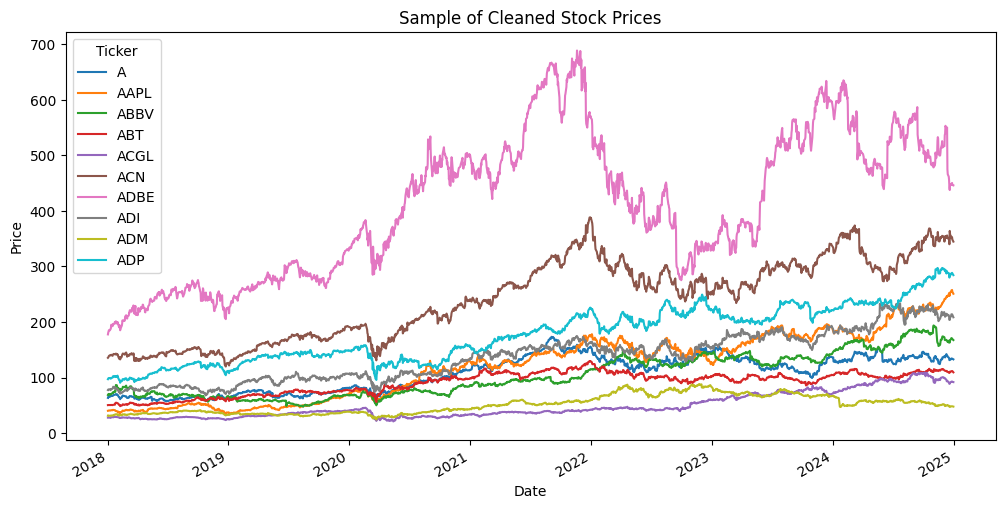

In [22]:
# Plot a few cleaned price series to check that the data looks reasonable
prices_clean.iloc[:, :10].plot(figsize=(12, 6), title="Sample of Cleaned Stock Prices")

plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

After cleaning, the dataset contains stocks with sufficiently complete price histories and no remaining missing values. I also removed any invalid non-positive prices before taking logs.

The cleaned price data will be used for return calculations, while the log price data will be used for cointegration testing, hedge ratio estimation, and spread construction.

## 5. Exploratory Data Analysis

In this section, I explore the cleaned stock price data before building the trading strategy. I first calculate daily log returns and visualize correlations between stocks.

This step is important because pairs trading often starts by looking for stocks that move together. However, high correlation does not necessarily mean cointegration. Correlation measures short-term co-movement in returns, while cointegration measures whether two price series have a stable long-run relationship.

In [25]:
# Calculate daily log returns
returns = log_prices.diff().dropna()

print("Log price data shape:", log_prices.shape)
print("Return data shape:", returns.shape)

returns.head()

Log price data shape: (1760, 477)
Return data shape: (1759, 477)


Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.025126,-0.000174,0.015527,0.002209,0.000906,0.004605,0.018621,0.012330,-0.007763,0.010805,...,0.008743,-0.010893,-0.006715,0.019450,0.012120,0.031031,-0.000858,0.006908,0.019668,0.004587
2018-01-04,-0.007530,0.004634,-0.005719,-0.001698,0.003727,0.011772,0.011970,-0.001095,0.016703,0.009507,...,-0.008177,0.005400,-0.007822,0.001383,0.006654,0.020953,0.010129,-0.001442,0.019567,0.005947
2018-01-05,0.015862,0.011321,0.017258,0.002886,-0.003953,0.008215,0.011504,0.004045,-0.006698,-0.000591,...,-0.001417,0.006649,-0.007028,-0.000807,-0.001876,0.076767,0.005811,0.009891,0.015456,0.011378
2018-01-08,0.002144,-0.003721,-0.016152,-0.002886,0.000113,0.007960,-0.001620,0.001744,-0.002242,-0.003048,...,0.006500,-0.013404,0.007453,0.004486,0.003604,-0.009280,0.001689,0.001903,0.009901,0.011924
2018-01-09,0.024257,-0.000115,0.007510,0.001698,-0.012984,0.003329,0.008931,-0.002071,0.003238,0.006929,...,-0.006783,0.006755,-0.011736,-0.004255,0.000288,0.002940,-0.002655,-0.016214,0.030183,0.011650


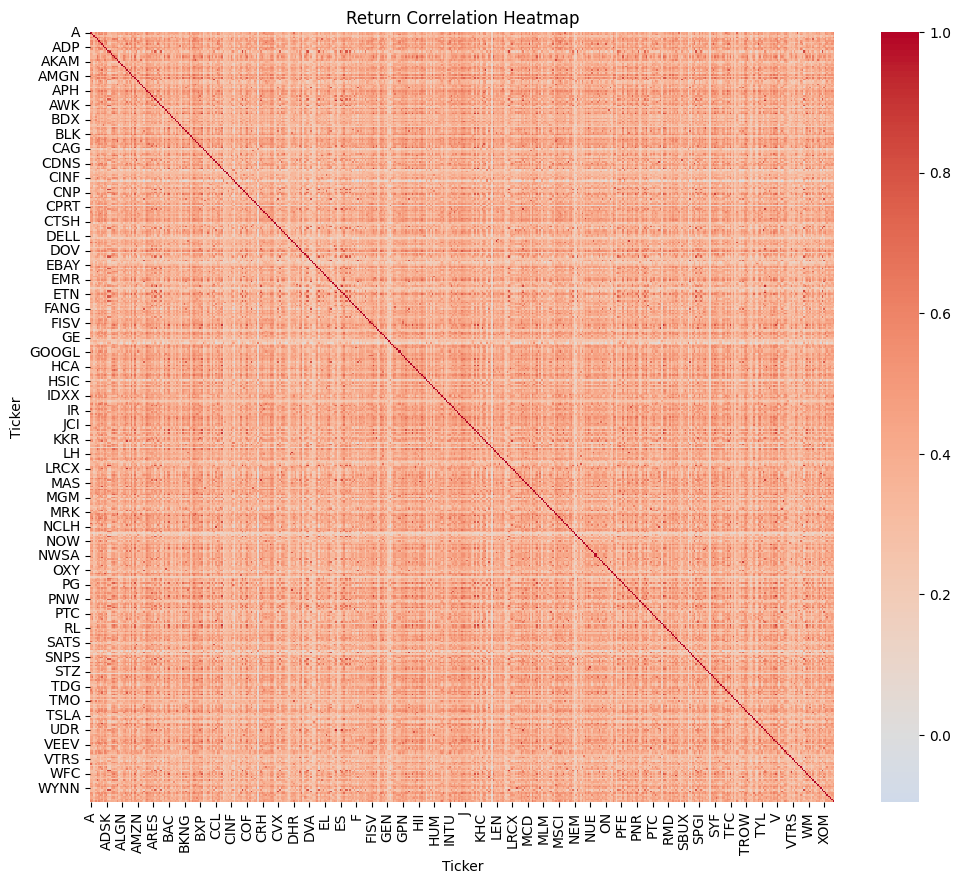

In [26]:
# Correlation matrix of returns
corr_matrix = returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Return Correlation Heatmap")
plt.show()

In [28]:
# Convert correlation matrix into pair table safely

corr_matrix_clean = corr_matrix.copy()

# Remove index/column names to avoid reset_index conflict
corr_matrix_clean.index.name = None
corr_matrix_clean.columns.name = None

# Keep only upper triangle so each pair appears once
upper_triangle = corr_matrix_clean.where(
    np.triu(np.ones(corr_matrix_clean.shape), k=1).astype(bool)
)

# Convert to table
corr_pairs = upper_triangle.stack().reset_index()

corr_pairs.columns = ["Stock 1", "Stock 2", "Correlation"]

# Sort from highest to lowest correlation
corr_pairs = corr_pairs.sort_values("Correlation", ascending=False)

corr_pairs.head(20)

,Stock 1,Stock 2,Correlation
94167,GOOG,GOOGL,0.995428
154395,NWS,NWSA,0.977471
75321,EQR,UDR,0.928462
87656,FRT,REG,0.926354
20191,AVB,EQR,0.923871
11241,AMAT,LRCX,0.920555
136778,MET,PRU,0.914251
20466,AVB,UDR,0.913393
40249,CFG,FITB,0.913235
86704,FITB,RF,0.912693


## 6. Feature Engineering

In this section, I create the main variables needed for the pairs trading strategy. I first split the cleaned data into an in-sample period and an out-of-sample period. The in-sample period is used to find cointegrated pairs and estimate the hedge ratio. The out-of-sample period is reserved for testing whether the strategy works on unseen data.

For each pair of stocks, I run an Engle-Granger cointegration test. Pairs with low p-values are considered stronger candidates because their prices appear to have a stable long-run relationship.

For the selected pair, I estimate the hedge ratio using linear regression, construct the spread, and convert the spread into a z-score. The z-score will later be used to generate trading signals.

In [29]:
# Split data into in-sample and out-of-sample periods

split_date = "2022-12-31"

train_log = log_prices.loc[:split_date]
test_log = log_prices.loc[split_date:]

train_prices = prices_clean.loc[:split_date]
test_prices = prices_clean.loc[split_date:]

print("Training period:", train_log.index.min(), "to", train_log.index.max())
print("Testing period:", test_log.index.min(), "to", test_log.index.max())

print("Training shape:", train_log.shape)
print("Testing shape:", test_log.shape)

Training period: 2018-01-02 00:00:00 to 2022-12-30 00:00:00
Testing period: 2023-01-03 00:00:00 to 2024-12-30 00:00:00
Training shape: (1259, 477)
Testing shape: (501, 477)


In [30]:
from itertools import combinations
from statsmodels.tsa.stattools import coint
from tqdm import tqdm

cointegration_results = []

stock_pairs = list(combinations(train_log.columns, 2))

for stock1, stock2 in tqdm(stock_pairs):
    try:
        score, pvalue, _ = coint(train_log[stock1], train_log[stock2])

        corr = train_log[[stock1, stock2]].corr().iloc[0, 1]

        cointegration_results.append({
            "stock1": stock1,
            "stock2": stock2,
            "coint_score": score,
            "pvalue": pvalue,
            "correlation": corr
        })

    except Exception:
        continue

coint_df = pd.DataFrame(cointegration_results)
coint_df = coint_df.sort_values("pvalue")

coint_df.head(20)

100%|██████████| 113526/113526 [40:12<00:00, 47.06it/s]


,stock1,stock2,coint_score,pvalue,correlation
113193,VTRS,XEL,-6.021983,0.000001,-0.935301
87223,KDP,MCD,-5.954616,0.000002,0.927641
24382,BDX,EVRG,-5.861286,0.000003,0.728016
53256,DHI,ITW,-5.838072,0.000004,0.974913
24315,BDX,CMS,-5.824881,0.000004,0.737335
24609,BDX,SRE,-5.772430,0.000005,0.716376
24486,BDX,LNT,-5.733611,0.000006,0.723085
24606,BDX,SO,-5.727672,0.000006,0.705135
24381,BDX,ETR,-5.725655,0.000006,0.719569
5619,AEE,VTRS,-5.686192,0.000007,-0.924681


In [31]:
coint_df.to_csv("../outputs/cointegration_results.csv", index=False)

In [32]:
pvalue_threshold = 0.05

candidate_pairs = coint_df[coint_df["pvalue"] < pvalue_threshold].copy()

print("Number of candidate cointegrated pairs:", len(candidate_pairs))

candidate_pairs.head(20)

Number of candidate cointegrated pairs: 7097


,stock1,stock2,coint_score,pvalue,correlation
113193,VTRS,XEL,-6.021983,0.000001,-0.935301
87223,KDP,MCD,-5.954616,0.000002,0.927641
24382,BDX,EVRG,-5.861286,0.000003,0.728016
53256,DHI,ITW,-5.838072,0.000004,0.974913
24315,BDX,CMS,-5.824881,0.000004,0.737335
24609,BDX,SRE,-5.772430,0.000005,0.716376
24486,BDX,LNT,-5.733611,0.000006,0.723085
24606,BDX,SO,-5.727672,0.000006,0.705135
24381,BDX,ETR,-5.725655,0.000006,0.719569
5619,AEE,VTRS,-5.686192,0.000007,-0.924681


In [ ]:
def analyze_pair(stock1, stock2, train_log, test_log, entry_threshold=2.0, exit_threshold=0.5):
    """
    Analyze one stock pair:
    1. Estimate hedge ratio
    2. Show full OLS regression results
    3. Construct spread
    4. Run ADF test
    5. Plot spread
    6. Plot z-score
    """
    import statsmodels.api as sm
    from statsmodels.tsa.stattools import adfuller
    import matplotlib.pyplot as plt

    # Estimate hedge ratio
    X = sm.add_constant(train_log[stock2])
    model = sm.OLS(train_log[stock1], X).fit()

    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]

    # Construct spread
    train_spread = train_log[stock1] - alpha - beta * train_log[stock2]
    test_spread = test_log[stock1] - alpha - beta * test_log[stock2]

    # ADF test on training spread
    adf_result = adfuller(train_spread.dropna())
    adf_stat = adf_result[0]
    adf_pvalue = adf_result[1]

    # Z-score
    spread_mean = train_spread.mean()
    spread_std = train_spread.std()

    train_z = (train_spread - spread_mean) / spread_std
    test_z = (test_spread - spread_mean) / spread_std

    print("Pair:", stock1, "-", stock2)
    print("Alpha:", alpha)
    print("Hedge ratio beta:", beta)
    print("Regression R-squared:", model.rsquared)
    print("ADF statistic:", adf_stat)
    print("ADF p-value:", adf_pvalue)

    if adf_pvalue < 0.05:
        print("Result: Spread appears stationary in-sample.")
    else:
        print("Result: Spread may not be stationary in-sample.")

    # Show full regression table
    display(model.summary())

    # Extra spread distribution stats
    spread_stats = pd.Series({
        "Spread Mean": train_spread.mean(),
        "Spread Std": train_spread.std(),
        "Spread Skew": train_spread.skew(),
        "Spread Kurtosis": train_spread.kurtosis(),
        "Spread Min": train_spread.min(),
        "Spread Max": train_spread.max()
    })

    display(spread_stats)

    # Plot spread
    plt.figure(figsize=(12, 5))
    plt.plot(train_spread, label="In-sample spread")
    plt.axhline(train_spread.mean(), linestyle="--", color="black", label="Mean")
    plt.title(f"In-Sample Spread: {stock1} and {stock2}")
    plt.xlabel("Date")
    plt.ylabel("Spread")
    plt.legend()
    plt.show()

    # Plot z-score
    plt.figure(figsize=(12, 5))
    plt.plot(train_z, label="In-sample z-score")
    plt.axhline(entry_threshold, linestyle="--", label="Upper entry")
    plt.axhline(-entry_threshold, linestyle="--", label="Lower entry")
    plt.axhline(exit_threshold, linestyle=":", label="Upper exit")
    plt.axhline(-exit_threshold, linestyle=":", label="Lower exit")
    plt.axhline(0, color="black", label="Mean")
    plt.title(f"In-Sample Z-Score: {stock1} and {stock2}")
    plt.xlabel("Date")
    plt.ylabel("Z-score")
    plt.legend()
    plt.show()

    return {
        "stock1": stock1,
        "stock2": stock2,
        "alpha": alpha,
        "beta": beta,
        "r_squared": model.rsquared,
        "adf_pvalue": adf_pvalue,
        "train_spread": train_spread,
        "test_spread": test_spread,
        "train_z": train_z,
        "test_z": test_z,
        "model": model,
        "spread_stats": spread_stats
    }

In [ ]:
def get_pair_stats(stock1, stock2, train_log):
    """
    For one stock pair, estimate:
    1. Hedge ratio beta
    2. Regression R-squared
    3. ADF p-value of the spread
    """
    import statsmodels.api as sm
    from statsmodels.tsa.stattools import adfuller

    # Estimate hedge ratio using OLS
    X = sm.add_constant(train_log[stock2])
    model = sm.OLS(train_log[stock1], X).fit()

    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]

    # Construct spread
    spread = train_log[stock1] - alpha - beta * train_log[stock2]

    # ADF test on spread
    adf_pvalue = adfuller(spread.dropna())[1]

    return alpha, beta, model.rsquared, adf_pvalue

In [ ]:
enhanced_results = []

# Use top 100 most cointegrated pairs first
top_candidates = coint_df.head(100).copy()

for _, row in top_candidates.iterrows():
    s1 = row["stock1"]
    s2 = row["stock2"]

    try:
        alpha, beta, r_squared, adf_pvalue = get_pair_stats(s1, s2, train_log)

        enhanced_results.append({
            "stock1": s1,
            "stock2": s2,
            "coint_pvalue": row["pvalue"],
            "correlation": row["correlation"],
            "alpha": alpha,
            "beta": beta,
            "r_squared": r_squared,
            "adf_pvalue": adf_pvalue
        })

    except Exception as e:
        print(f"Skipping {s1}-{s2}: {e}")

enhanced_pairs = pd.DataFrame(enhanced_results)

enhanced_pairs.sort_values("coint_pvalue").head(20)

,stock1,stock2,coint_pvalue,correlation,alpha,beta,r_squared,adf_pvalue
0,VTRS,XEL,0.000001,-0.935301,10.874161,-2.074892,0.874787,1.502498e-07
1,KDP,MCD,0.000002,0.927641,-2.755199,1.150317,0.860518,1.735922e-07
2,BDX,EVRG,0.000003,0.728016,3.669495,0.382212,0.530007,3.447135e-07
3,DHI,ITW,0.000004,0.974913,-3.596202,1.510705,0.950456,3.879917e-07
4,BDX,CMS,0.000004,0.737335,3.954845,0.307466,0.543663,4.151231e-07
5,BDX,SRE,0.000005,0.716376,3.971982,0.294329,0.513194,5.416103e-07
6,BDX,LNT,0.000006,0.723085,4.080330,0.285230,0.522852,6.591975e-07
7,BDX,SO,0.000006,0.705135,4.327145,0.213946,0.497216,6.789282e-07
8,BDX,ETR,0.000006,0.719569,4.144906,0.271020,0.517779,6.860034e-07
9,AEE,VTRS,0.000007,-0.924681,5.201923,-0.382237,0.855035,8.374174e-07


In [46]:
good_pairs = enhanced_pairs[
    (enhanced_pairs["coint_pvalue"] < 0.05) &
    (enhanced_pairs["adf_pvalue"] < 0.05) &
    (enhanced_pairs["correlation"] > 0.7) &
    (enhanced_pairs["beta"] > 0)
].copy()

good_pairs = good_pairs.sort_values("coint_pvalue")

print("Number of good pairs:", len(good_pairs))

good_pairs.head(20)

Number of good pairs: 42


,stock1,stock2,coint_pvalue,correlation,alpha,beta,r_squared,adf_pvalue
1,KDP,MCD,0.000002,0.927641,-2.755199,1.150317,0.860518,1.735922e-07
2,BDX,EVRG,0.000003,0.728016,3.669495,0.382212,0.530007,3.447135e-07
3,DHI,ITW,0.000004,0.974913,-3.596202,1.510705,0.950456,3.879917e-07
4,BDX,CMS,0.000004,0.737335,3.954845,0.307466,0.543663,4.151231e-07
5,BDX,SRE,0.000005,0.716376,3.971982,0.294329,0.513194,5.416103e-07
6,BDX,LNT,0.000006,0.723085,4.080330,0.285230,0.522852,6.591975e-07
7,BDX,SO,0.000006,0.705135,4.327145,0.213946,0.497216,6.789282e-07
8,BDX,ETR,0.000006,0.719569,4.144906,0.271020,0.517779,6.860034e-07
10,BKNG,MGM,0.000008,0.889173,2.943357,0.412765,0.790628,8.480105e-07
12,CFG,MGM,0.000011,0.967267,0.621922,0.806422,0.935605,1.254163e-06


Pair: BDX - SRE
Alpha: 3.971982394357987
Hedge ratio beta: 0.29432865909430816
Regression R-squared: 0.5131939043526115
ADF statistic: -5.770146405101592
ADF p-value: 5.416102985146832e-07
Result: Spread appears stationary in-sample.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    BDX   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     1325.
Date:                Sat, 09 May 2026   Prob (F-statistic):          1.00e-198
Time:                        22:43:57   Log-Likelihood:                 2063.1
No. Observations:                1259   AIC:                            -4122.
Df Residuals:                    1257   BIC:                            -4112.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9720      0.032    122.840      0.000       3.909       4.035
SRE            0.2943      0.008     36.402      0.000       0.278       0.310
==============================================================================
Omnibus:                        0.418   Durbin-Watson:                   0.100
Prob(Omnibus):                  0.811   Jarque-Bera (JB):                0.319
Skew:                           0.017   Prob(JB):                        0.853
Kurtosis:                       3.070   Cond. No.                         104.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Spread Mean       -9.420582e-15
Spread Std         4.701896e-02
Spread Skew        1.738844e-02
Spread Kurtosis    7.487914e-02
Spread Min        -1.515711e-01
Spread Max         1.560233e-01
dtype: float64

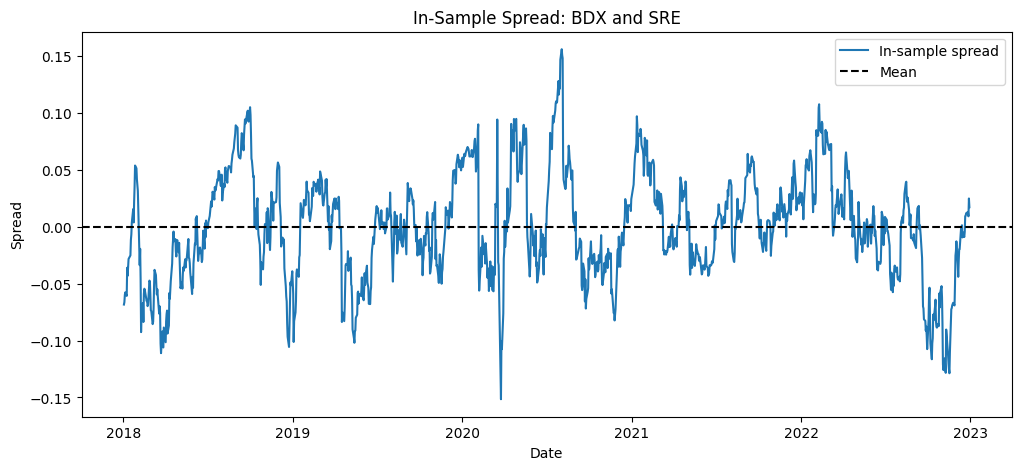

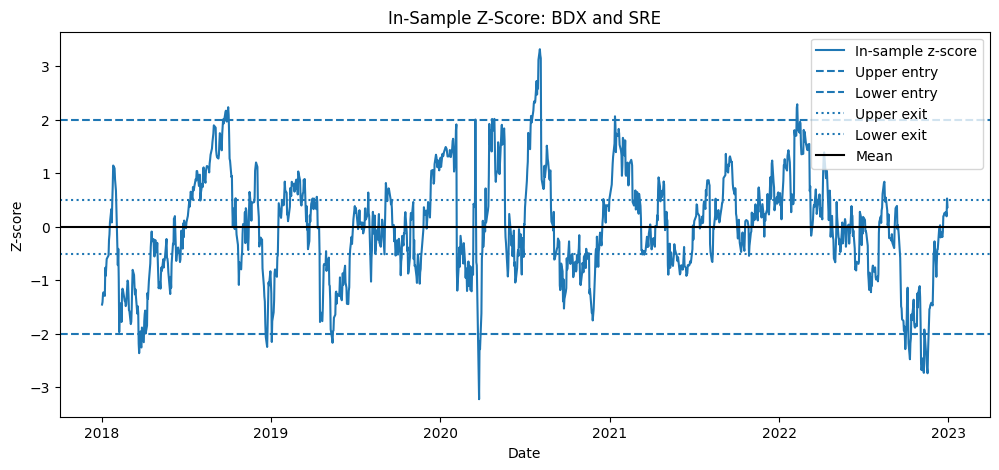

In [288]:
row_number = 4 #Change this to test different pairs

stock1 = good_pairs.iloc[row_number]["stock1"]
stock2 = good_pairs.iloc[row_number]["stock2"]

pair_analysis = analyze_pair(stock1, stock2, train_log, test_log)

## 7. Model Building: Rolling Z-Score Pairs Trading Strategy

In this section, I build the final pairs trading model using a rolling z-score instead of a fixed in-sample z-score. The fixed approach estimates the spread mean and standard deviation using only the training period and keeps them constant throughout the test period. However, this may be too rigid because the relationship between two stocks can change over time.

To make the strategy more adaptive, I use a rolling window to calculate the spread mean and standard deviation. This means the model evaluates whether the current spread is unusually high or low relative to its recent behavior rather than relative to a fixed historical average.

The strategy uses the following rules:

- If the rolling z-score is above the upper entry threshold, the strategy shorts the spread.
- If the rolling z-score is below the lower entry threshold, the strategy longs the spread.
- If the rolling z-score returns close to zero, the strategy exits the position.

The selected pair is BDX-EVRG because it has a stationary in-sample spread, a positive hedge ratio, and more reasonable out-of-sample trading behavior than other candidate pairs.

In [289]:
stock1 = pair_analysis["stock1"]
stock2 = pair_analysis["stock2"]

alpha = pair_analysis["alpha"]
beta = pair_analysis["beta"]

train_spread = pair_analysis["train_spread"]
test_spread = pair_analysis["test_spread"]

print("Selected pair:", stock1, "-", stock2)
print("Alpha:", alpha)
print("Beta:", beta)

Selected pair: BDX - SRE
Alpha: 3.971982394357987
Beta: 0.29432865909430816


In [290]:
full_spread = pd.concat([train_spread, test_spread])

full_spread = full_spread.sort_index()

full_spread.head()

Date
2018-01-02   -0.068380
2018-01-03   -0.066252
2018-01-04   -0.059751
2018-01-05   -0.057639
2018-01-08   -0.060788
dtype: float64

In [291]:
def calculate_rolling_zscore(spread, window=60):
    """
    Calculate rolling z-score of the spread.

    z-score = (spread - rolling mean) / rolling standard deviation
    """
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()

    zscore = (spread - rolling_mean) / rolling_std

    return zscore

In [292]:
rolling_window = 60

full_z_rolling = calculate_rolling_zscore(full_spread, window=rolling_window)

# Keep only the out-of-sample z-score for testing
test_z = full_z_rolling.loc[test_spread.index].dropna()

test_z.head()

Date
2023-01-03    1.770728
2023-01-04    1.790130
2023-01-05    1.604312
2023-01-06    1.764511
2023-01-09    1.084761
dtype: float64

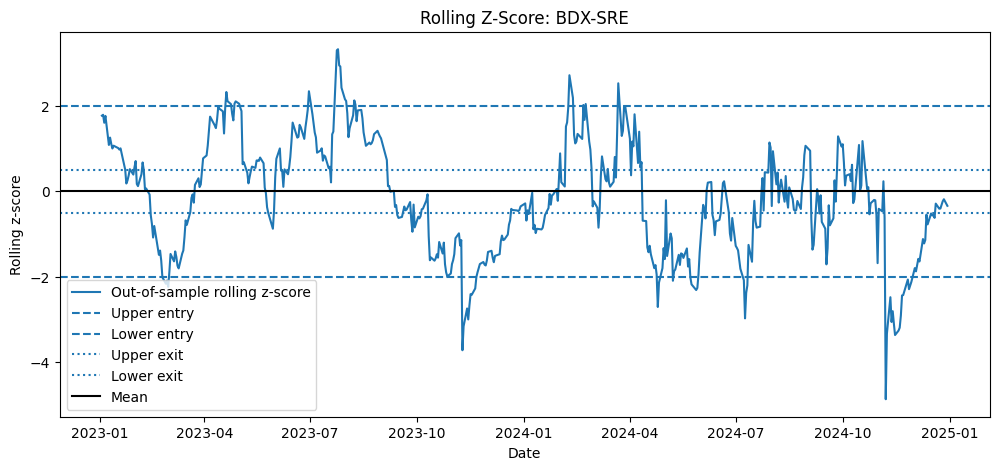

In [293]:
entry_threshold = 2.0
exit_threshold = 0.5

plt.figure(figsize=(12, 5))

plt.plot(test_z, label="Out-of-sample rolling z-score")
plt.axhline(entry_threshold, linestyle="--", label="Upper entry")
plt.axhline(-entry_threshold, linestyle="--", label="Lower entry")
plt.axhline(exit_threshold, linestyle=":", label="Upper exit")
plt.axhline(-exit_threshold, linestyle=":", label="Lower exit")
plt.axhline(0, color="black", label="Mean")

plt.title(f"Rolling Z-Score: {stock1}-{stock2}")
plt.xlabel("Date")
plt.ylabel("Rolling z-score")
plt.legend()
plt.show()

In [294]:
def generate_positions(zscore, entry_threshold=2.0, exit_threshold=0.5):
    """
    Generate trading positions based on spread z-score.

    position = 1 means long spread
    position = -1 means short spread
    position = 0 means no position
    """
    positions = pd.Series(index=zscore.index, dtype=float)
    current_position = 0

    for date in zscore.index:
        z = zscore.loc[date]

        if current_position == 0:
            if z > entry_threshold:
                current_position = -1
            elif z < -entry_threshold:
                current_position = 1

        elif current_position == 1:
            if z >= -exit_threshold:
                current_position = 0

        elif current_position == -1:
            if z <= exit_threshold:
                current_position = 0

        positions.loc[date] = current_position

    return positions

In [295]:
test_positions = generate_positions(
    test_z,
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold
)

test_positions.value_counts()

 0.0    323
 1.0    104
-1.0     74
Name: count, dtype: int64

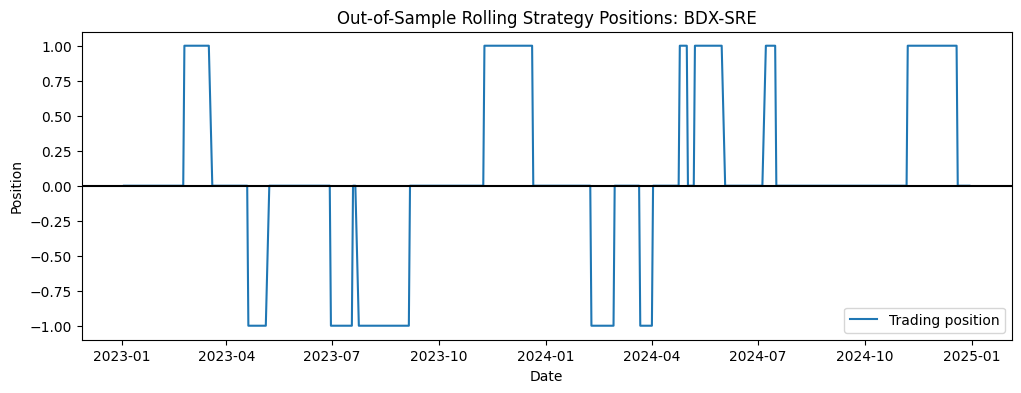

In [296]:
plt.figure(figsize=(12, 4))

plt.plot(test_positions, label="Trading position")
plt.axhline(0, color="black")

plt.title(f"Out-of-Sample Rolling Strategy Positions: {stock1}-{stock2}")
plt.xlabel("Date")
plt.ylabel("Position")
plt.legend()
plt.show()

In [297]:
signals = pd.DataFrame({
    "z_score": test_z,
    "position": test_positions
})

signals["position_change"] = signals["position"].diff().fillna(0)

signals.head()

,z_score,position,position_change
Date,,,
2023-01-03,1.770728,0.0,0.0
2023-01-04,1.790130,0.0,0.0
2023-01-05,1.604312,0.0,0.0
2023-01-06,1.764511,0.0,0.0
2023-01-09,1.084761,0.0,0.0


In [298]:
trade_signals = signals[signals["position_change"] != 0].copy()

trade_signals

,z_score,position,position_change
Date,,,
2023-02-24,-2.014853,1.0,1.0
2023-03-20,-0.487757,0.0,-1.0
2023-04-20,2.324206,-1.0,-1.0
2023-05-08,0.434514,0.0,1.0
2023-06-30,2.341363,-1.0,-1.0
2023-07-19,0.207454,0.0,1.0
2023-07-24,3.300684,-1.0,-1.0
2023-09-06,0.119110,0.0,1.0
2023-11-09,-3.722407,1.0,1.0


## 8. Model Evaluation

In this section, I evaluate the pairs trading strategy from the previous part using an out-of-sample backtest. The strategy uses the positions generated from the z-score trading rule in the previous section.

The backtest calculates daily strategy returns, applies transaction costs whenever the position changes, and then evaluates performance using cumulative return, annualized return, annualized volatility, Sharpe ratio, maximum drawdown, win rate, average trade return, and turnover.

This section focuses on out-of-sample performance because the strategy should be judged on data that was not used to select the pair or estimate the hedge ratio.

In [299]:
# Daily log returns for the two stocks in the selected pair
ret1 = test_log[stock1].diff()
ret2 = test_log[stock2].diff()

# Spread return based on the hedge ratio
spread_returns = ret1 - beta * ret2

# Align returns with the rolling z-score dates
spread_returns = spread_returns.loc[test_z.index]

spread_returns.head()

Date
2023-01-03         NaN
2023-01-04    0.004892
2023-01-05   -0.005929
2023-01-06    0.011712
2023-01-09   -0.031819
dtype: float64

In [300]:
# Use yesterday's position to earn today's return
# This avoids look-ahead bias
strategy_returns_before_cost = test_positions.shift(1) * spread_returns

strategy_returns_before_cost = strategy_returns_before_cost.dropna()

strategy_returns_before_cost.head()

Date
2023-01-04    0.0
2023-01-05   -0.0
2023-01-06    0.0
2023-01-09   -0.0
2023-01-10    0.0
dtype: float64

In [301]:
# Transaction cost assumption
# 0.0005 means 5 basis points per position change
transaction_cost = 0.0005

# Position changes represent trades
position_changes = test_positions.diff().abs().fillna(0)

# Apply transaction cost whenever position changes
costs = position_changes * transaction_cost

# Strategy returns after transaction costs
strategy_returns_after_cost = strategy_returns_before_cost - costs.loc[strategy_returns_before_cost.index]

strategy_returns_after_cost = strategy_returns_after_cost.dropna()

strategy_returns_after_cost.head()

Date
2023-01-04    0.0
2023-01-05   -0.0
2023-01-06    0.0
2023-01-09   -0.0
2023-01-10    0.0
dtype: float64

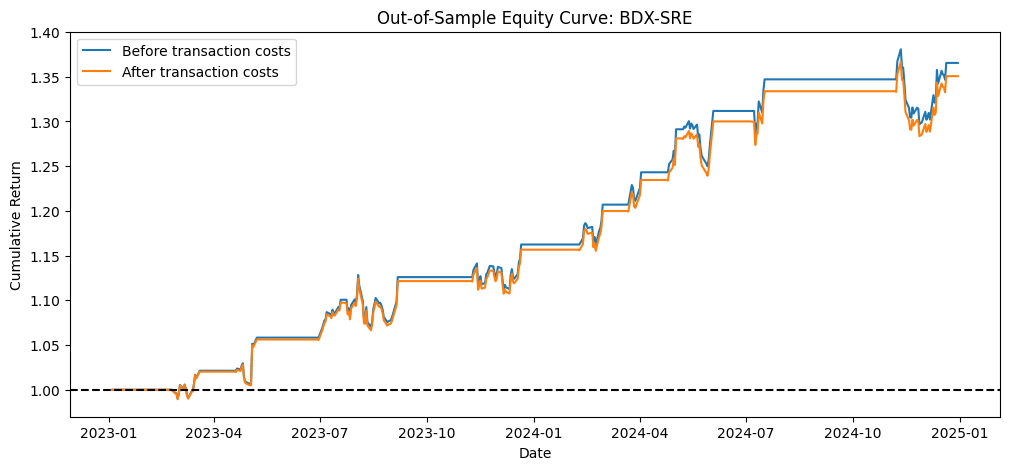

In [302]:
equity_before_cost = (1 + strategy_returns_before_cost).cumprod()
equity_after_cost = (1 + strategy_returns_after_cost).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(equity_before_cost, label="Before transaction costs")
plt.plot(equity_after_cost, label="After transaction costs")
plt.axhline(1, color="black", linestyle="--")

plt.title(f"Out-of-Sample Equity Curve: {stock1}-{stock2}")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

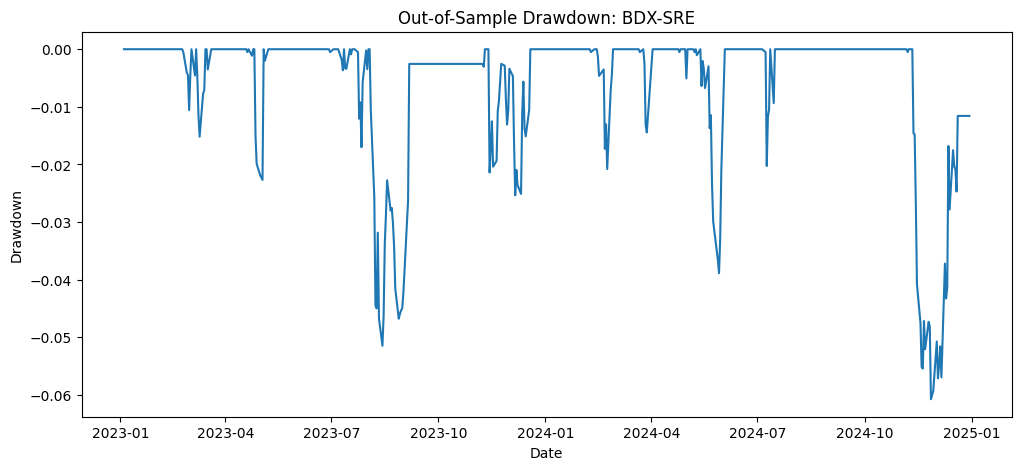

In [303]:
running_max = equity_after_cost.cummax()
drawdown = equity_after_cost / running_max - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown)

plt.title(f"Out-of-Sample Drawdown: {stock1}-{stock2}")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

In [304]:
def calculate_performance_metrics(returns, positions, periods_per_year=252):
    """
    Calculate common backtest performance metrics.
    """
    returns = returns.dropna()

    cumulative_return = (1 + returns).prod() - 1

    annualized_return = (1 + cumulative_return) ** (periods_per_year / len(returns)) - 1

    annualized_volatility = returns.std() * np.sqrt(periods_per_year)

    sharpe_ratio = (
        annualized_return / annualized_volatility
        if annualized_volatility != 0
        else np.nan
    )

    equity_curve = (1 + returns).cumprod()
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1
    max_drawdown = drawdown.min()

    win_rate = (returns > 0).mean()
    average_daily_return = returns.mean()

    # Turnover = average absolute daily position change
    turnover = positions.diff().abs().mean()

    # Number of trades = number of nonzero position changes
    number_of_trades = (positions.diff().fillna(0) != 0).sum()

    return {
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
        "Win Rate": win_rate,
        "Average Daily Return": average_daily_return,
        "Turnover": turnover,
        "Number of Trades": number_of_trades
    }

In [305]:
metrics_before_cost = calculate_performance_metrics(
    strategy_returns_before_cost,
    test_positions
)

metrics_after_cost = calculate_performance_metrics(
    strategy_returns_after_cost,
    test_positions
)

performance_table = pd.DataFrame({
    "Before Transaction Costs": metrics_before_cost,
    "After Transaction Costs": metrics_after_cost
})

performance_table

,Before Transaction Costs,After Transaction Costs
Cumulative Return,0.365457,0.350628
Annualized Return,0.169984,0.163563
Annualized Volatility,0.092139,0.091724
Sharpe Ratio,1.844863,1.783218
Max Drawdown,-0.060734,-0.060734
Win Rate,0.192000,0.192000
Average Daily Return,0.000640,0.000618
Turnover,0.044000,0.044000
Number of Trades,22.000000,22.000000


In [306]:
trade_log = pd.DataFrame({
    "stock1": stock1,
    "stock2": stock2,
    "z_score": test_z,
    "position": test_positions,
    "position_change": test_positions.diff().fillna(0),
    "spread_return": spread_returns,
    "strategy_return_before_cost": strategy_returns_before_cost,
    "transaction_cost": costs,
    "strategy_return_after_cost": strategy_returns_after_cost,
    "equity_after_cost": equity_after_cost
})

trade_log.head()

,stock1,stock2,z_score,position,position_change,spread_return,strategy_return_before_cost,transaction_cost,strategy_return_after_cost,equity_after_cost
Date,,,,,,,,,,
2023-01-03,BDX,SRE,1.770728,0.0,0.0,NaN,NaN,0.0,NaN,NaN
2023-01-04,BDX,SRE,1.790130,0.0,0.0,0.004892,0.0,0.0,0.0,1.0
2023-01-05,BDX,SRE,1.604312,0.0,0.0,-0.005929,-0.0,0.0,-0.0,1.0
2023-01-06,BDX,SRE,1.764511,0.0,0.0,0.011712,0.0,0.0,0.0,1.0
2023-01-09,BDX,SRE,1.084761,0.0,0.0,-0.031819,-0.0,0.0,-0.0,1.0


In [307]:
trade_dates = trade_log[trade_log["position_change"] != 0].copy()

trade_dates

,stock1,stock2,z_score,position,position_change,spread_return,strategy_return_before_cost,transaction_cost,strategy_return_after_cost,equity_after_cost
Date,,,,,,,,,,
2023-02-24,BDX,SRE,-2.014853,1.0,1.0,-0.006818,-0.000000,0.0005,-0.000500,0.999500
2023-03-20,BDX,SRE,-0.487757,0.0,-1.0,0.007915,0.007915,0.0005,0.007415,1.020283
2023-04-20,BDX,SRE,2.324206,-1.0,-1.0,0.013715,0.000000,0.0005,-0.000500,1.019773
2023-05-08,BDX,SRE,0.434514,0.0,1.0,-0.008571,0.008571,0.0005,0.008071,1.056209
2023-06-30,BDX,SRE,2.341363,-1.0,-1.0,0.011889,0.000000,0.0005,-0.000500,1.055681
2023-07-19,BDX,SRE,0.207454,0.0,1.0,-0.008523,0.008523,0.0005,0.008023,1.097380
2023-07-24,BDX,SRE,3.300684,-1.0,-1.0,0.055206,0.000000,0.0005,-0.000500,1.096832
2023-09-06,BDX,SRE,0.119110,0.0,1.0,-0.024872,0.024872,0.0005,0.024372,1.121500
2023-11-09,BDX,SRE,-3.722407,1.0,1.0,-0.093060,-0.000000,0.0005,-0.000500,1.120939


In [308]:
trade_log.to_csv("../outputs/trade_log_bdx_evrg.csv")
performance_table.to_csv("../outputs/performance_table_bdx_evrg.csv")

In [ ]:
def run_rolling_pair_backtest(
    stock1,
    stock2,
    train_log,
    test_log,
    rolling_window=60,
    entry_threshold=2.0,
    exit_threshold=0.5,
    transaction_cost=0.0005
):
    """
    Runs the full rolling z-score pairs trading backtest for one pair.

    Steps:
    1. Estimate hedge ratio using in-sample data.
    2. Construct train/test spread.
    3. Calculate rolling z-score.
    4. Generate positions.
    5. Calculate strategy returns before and after transaction costs.
    """
    import statsmodels.api as sm

    # Estimate hedge ratio on in-sample period
    X = sm.add_constant(train_log[stock2])
    model = sm.OLS(train_log[stock1], X).fit()

    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]

    # Construct spread
    train_spread = train_log[stock1] - alpha - beta * train_log[stock2]
    test_spread = test_log[stock1] - alpha - beta * test_log[stock2]

    # Use train + test spread so rolling window has enough history at start of test
    full_spread = pd.concat([train_spread, test_spread]).sort_index()

    # Rolling z-score
    full_z = calculate_rolling_zscore(full_spread, window=rolling_window)
    train_z = full_z.loc[train_spread.index].dropna()
    test_z = full_z.loc[test_spread.index].dropna()

    # Positions
    train_positions = generate_positions(
        train_z,
        entry_threshold=entry_threshold,
        exit_threshold=exit_threshold
    )

    test_positions = generate_positions(
        test_z,
        entry_threshold=entry_threshold,
        exit_threshold=exit_threshold
    )

    # Spread returns
    train_ret1 = train_log[stock1].diff()
    train_ret2 = train_log[stock2].diff()
    train_spread_returns = train_ret1 - beta * train_ret2
    train_spread_returns = train_spread_returns.loc[train_z.index]

    test_ret1 = test_log[stock1].diff()
    test_ret2 = test_log[stock2].diff()
    test_spread_returns = test_ret1 - beta * test_ret2
    test_spread_returns = test_spread_returns.loc[test_z.index]

    # Strategy returns before cost
    train_returns_before_cost = (
        train_positions.shift(1) * train_spread_returns
    ).dropna()

    test_returns_before_cost = (
        test_positions.shift(1) * test_spread_returns
    ).dropna()

    # Transaction costs
    train_position_changes = train_positions.diff().abs().fillna(0)
    test_position_changes = test_positions.diff().abs().fillna(0)

    train_costs = train_position_changes * transaction_cost
    test_costs = test_position_changes * transaction_cost

    train_returns_after_cost = (
        train_returns_before_cost
        - train_costs.loc[train_returns_before_cost.index]
    ).dropna()

    test_returns_after_cost = (
        test_returns_before_cost
        - test_costs.loc[test_returns_before_cost.index]
    ).dropna()

    return {
        "stock1": stock1,
        "stock2": stock2,
        "alpha": alpha,
        "beta": beta,
        "model": model,
        "train_spread": train_spread,
        "test_spread": test_spread,
        "train_z": train_z,
        "test_z": test_z,
        "train_positions": train_positions,
        "test_positions": test_positions,
        "train_returns_before_cost": train_returns_before_cost,
        "test_returns_before_cost": test_returns_before_cost,
        "train_returns_after_cost": train_returns_after_cost,
        "test_returns_after_cost": test_returns_after_cost,
        "train_costs": train_costs,
        "test_costs": test_costs
    }

### 8.1 In-Sample vs Out-of-Sample Comparison

To check whether the model generalizes beyond the training period, I compare the rolling z-score strategy's in-sample and out-of-sample performance. The in-sample period is the data used to identify the pair and estimate the hedge ratio, while the out-of-sample period is unseen data used to test whether the strategy still works.

This comparison is important because a pairs trading strategy can look strong in-sample but fail out-of-sample if the relationship between the two stocks breaks down.

In [310]:
final_stock1 = stock1
final_stock2 = stock2

# Final model parameters
rolling_window = 60
entry_threshold = 2.0
exit_threshold = 0.5
transaction_cost = 0.0005

final_result = run_rolling_pair_backtest(
    final_stock1,
    final_stock2,
    train_log,
    test_log,
    rolling_window=rolling_window,
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    transaction_cost=transaction_cost
)

train_metrics = calculate_performance_metrics(
    final_result["train_returns_after_cost"],
    final_result["train_positions"]
)

test_metrics = calculate_performance_metrics(
    final_result["test_returns_after_cost"],
    final_result["test_positions"]
)

in_sample_vs_out_sample = pd.DataFrame({
    "In-Sample": train_metrics,
    "Out-of-Sample": test_metrics
})

in_sample_vs_out_sample

,In-Sample,Out-of-Sample
Cumulative Return,1.212305,0.350628
Annualized Return,0.181620,0.163563
Annualized Volatility,0.145236,0.091724
Sharpe Ratio,1.250514,1.783218
Max Drawdown,-0.107126,-0.060734
Win Rate,0.200167,0.192000
Average Daily Return,0.000703,0.000618
Turnover,0.040867,0.044000
Number of Trades,49.000000,22.000000


The in-sample vs out-of-sample table compares the strategy's performance before and after the testing split. The out-of-sample results are more important because they show whether the strategy works on unseen data. If the in-sample performance is much stronger than the out-of-sample performance, that may indicate overfitting.

### 8.2 Sensitivity Analysis

I test different rolling windows, entry thresholds, and exit thresholds to see whether the strategy depends too heavily on one specific parameter choice. A more reliable strategy should remain profitable under nearby parameter settings rather than only working for one exact combination.

The parameters tested are:

- Rolling window: 30, 60, 90 days
- Entry threshold: 1.5, 2.0, 2.5
- Exit threshold: 0.25, 0.5, 0.75

In [ ]:
sensitivity_results = []

entry_thresholds = [1.5, 2.0, 2.5]
exit_thresholds = [0.25, 0.5, 0.75]
rolling_windows = [30, 60, 90]

for window in rolling_windows:
    for entry in entry_thresholds:
        for exit_ in exit_thresholds:

            if exit_ >= entry:
                continue

            try:
                temp_result = run_rolling_pair_backtest(
                    final_stock1,
                    final_stock2,
                    train_log,
                    test_log,
                    rolling_window=window,
                    entry_threshold=entry,
                    exit_threshold=exit_,
                    transaction_cost=transaction_cost
                )

                temp_metrics = calculate_performance_metrics(
                    temp_result["test_returns_after_cost"],
                    temp_result["test_positions"]
                )

                sensitivity_results.append({
                    "Rolling Window": window,
                    "Entry Threshold": entry,
                    "Exit Threshold": exit_,
                    "Cumulative Return": temp_metrics["Cumulative Return"],
                    "Annualized Return": temp_metrics["Annualized Return"],
                    "Annualized Volatility": temp_metrics["Annualized Volatility"],
                    "Sharpe Ratio": temp_metrics["Sharpe Ratio"],
                    "Max Drawdown": temp_metrics["Max Drawdown"],
                    "Win Rate": temp_metrics["Win Rate"],
                    "Turnover": temp_metrics["Turnover"],
                    "Number of Trades": temp_metrics["Number of Trades"]
                })

            except Exception as e:
                print(f"Skipped window={window}, entry={entry}, exit={exit_}: {e}")

sensitivity_table = pd.DataFrame(sensitivity_results)

sensitivity_table.sort_values("Sharpe Ratio", ascending=False).head(15)
sensitivity_table.to_csv("sensitivity_analysis.csv", index=False)

In [313]:
# Sort sensitivity table by Sharpe ratio
sensitivity_table_sorted = sensitivity_table.sort_values("Sharpe Ratio", ascending=False)

# Display top 15 parameter combinations
display(sensitivity_table_sorted.head(15))

# Print the best parameter combination
best_params = sensitivity_table_sorted.iloc[0]

print("Best parameter combination:")
print("Rolling Window:", best_params["Rolling Window"])
print("Entry Threshold:", best_params["Entry Threshold"])
print("Exit Threshold:", best_params["Exit Threshold"])
print("Cumulative Return:", best_params["Cumulative Return"])
print("Annualized Return:", best_params["Annualized Return"])
print("Sharpe Ratio:", best_params["Sharpe Ratio"])
print("Max Drawdown:", best_params["Max Drawdown"])
print("Number of Trades:", best_params["Number of Trades"])

,Rolling Window,Entry Threshold,Exit Threshold,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Turnover,Number of Trades
12,60,2.0,0.25,0.404255,0.186623,0.100066,1.865011,-0.060734,0.218,0.044,22
13,60,2.0,0.50,0.350628,0.163563,0.091724,1.783218,-0.060734,0.192,0.044,22
5,30,2.0,0.75,0.314637,0.147831,0.089139,1.658434,-0.072434,0.194,0.076,38
2,30,1.5,0.75,0.370643,0.172222,0.107329,1.604617,-0.084946,0.250,0.110,55
23,90,2.0,0.75,0.285109,0.134765,0.088409,1.524324,-0.060734,0.144,0.036,18
16,60,2.5,0.50,0.237210,0.113247,0.076022,1.489666,-0.060734,0.136,0.028,14
4,30,2.0,0.50,0.301344,0.141967,0.096046,1.478108,-0.072434,0.222,0.076,38
1,30,1.5,0.50,0.353542,0.164828,0.112011,1.471532,-0.084946,0.272,0.106,53
15,60,2.5,0.25,0.253644,0.120675,0.084390,1.429972,-0.060734,0.156,0.028,14
21,90,2.0,0.25,0.312619,0.146943,0.103173,1.424241,-0.060734,0.194,0.030,15


Best parameter combination:
Rolling Window: 60.0
Entry Threshold: 2.0
Exit Threshold: 0.25
Cumulative Return: 0.40425549340492695
Annualized Return: 0.1866232414725102
Sharpe Ratio: 1.865010799098386
Max Drawdown: -0.0607339860645808
Number of Trades: 22.0


The sensitivity analysis shows how the model performs under different parameter choices. This helps check whether the final result is robust or whether it only works for one specific rolling window and threshold combination. I focus on combinations with strong Sharpe ratios, positive cumulative returns, controlled drawdowns, and reasonable trade counts.

### 8.3 Average Trade Return

The earlier performance table reports daily metrics such as Sharpe ratio, volatility, and daily win rate. However, pairs trades often last multiple days, so I also calculate trade-level returns. This helps determine whether the strategy is profitable on completed trading episodes rather than only on individual days.

In [314]:
def calculate_trade_returns(strategy_returns, positions):
    """
    Groups daily strategy returns into trade-level returns.

    A trade starts when the lagged position becomes nonzero.
    A trade ends when the lagged position returns to zero or changes direction.
    """
    active_position = positions.shift(1).reindex(strategy_returns.index).fillna(0)

    trades = []
    current_trade_returns = []
    current_direction = 0
    start_date = None

    for date in strategy_returns.index:
        pos = active_position.loc[date]
        ret = strategy_returns.loc[date]

        # Start a new trade
        if current_direction == 0 and pos != 0:
            current_direction = pos
            start_date = date
            current_trade_returns = [ret]

        # Continue current trade
        elif current_direction != 0 and pos == current_direction:
            current_trade_returns.append(ret)

        # Trade ends or changes direction
        elif current_direction != 0 and pos != current_direction:
            end_date = date

            trade_return = (1 + pd.Series(current_trade_returns)).prod() - 1

            trades.append({
                "Start Date": start_date,
                "End Date": end_date,
                "Direction": current_direction,
                "Trade Return": trade_return,
                "Holding Days": len(current_trade_returns)
            })

            # If new position starts immediately
            if pos != 0:
                current_direction = pos
                start_date = date
                current_trade_returns = [ret]
            else:
                current_direction = 0
                start_date = None
                current_trade_returns = []

    # If a trade is still open at the end
    if current_direction != 0 and len(current_trade_returns) > 0:
        trade_return = (1 + pd.Series(current_trade_returns)).prod() - 1

        trades.append({
            "Start Date": start_date,
            "End Date": strategy_returns.index[-1],
            "Direction": current_direction,
            "Trade Return": trade_return,
            "Holding Days": len(current_trade_returns)
        })

    return pd.DataFrame(trades)

In [315]:
trade_return_table = calculate_trade_returns(
    final_result["test_returns_after_cost"],
    final_result["test_positions"]
)

trade_return_table

,Start Date,End Date,Direction,Trade Return,Holding Days
0,2023-02-27,2023-03-21,1.0,0.020793,16
1,2023-04-21,2023-05-09,-1.0,0.035730,12
2,2023-07-03,2023-07-20,-1.0,0.039500,12
3,2023-07-25,2023-09-07,-1.0,0.022491,31
4,2023-11-10,2023-12-22,1.0,0.031859,29
5,2024-02-12,2024-03-01,-1.0,0.037857,13
6,2024-03-25,2024-04-03,-1.0,0.029445,6
7,2024-04-26,2024-05-03,1.0,0.038171,5
8,2024-05-09,2024-06-04,1.0,0.015372,17
9,2024-07-09,2024-07-18,1.0,0.026441,7


In [316]:
average_trade_return = trade_return_table["Trade Return"].mean()
trade_win_rate = (trade_return_table["Trade Return"] > 0).mean()
average_holding_days = trade_return_table["Holding Days"].mean()

trade_summary = pd.Series({
    "Average Trade Return": average_trade_return,
    "Trade-Level Win Rate": trade_win_rate,
    "Average Holding Days": average_holding_days,
    "Number of Completed/Open Trades": len(trade_return_table)
})

trade_summary

Average Trade Return                0.028254
Trade-Level Win Rate                1.000000
Average Holding Days               16.181818
Number of Completed/Open Trades    11.000000
dtype: float64

The trade-level return table groups daily strategy returns into individual trading episodes. This provides a clearer measure of trade profitability than the daily win rate because each trade can last multiple days. The average trade return and trade-level win rate help evaluate whether the model consistently earns money when it enters positions.

### 8.4 Overall Portfolio Cumulative Return

In addition to analyzing the final selected pair, I also test an equal-weighted portfolio of multiple candidate pairs. This checks whether the strategy can work across several pairs instead of depending entirely on one selected pair.

For each candidate pair, I run the same rolling z-score strategy and calculate out-of-sample after-cost returns. I then average the daily returns across pairs to create an equal-weighted pairs trading portfolio.

In [317]:
# Choose candidate pairs for portfolio test
# You can change 10 to a larger or smaller number
portfolio_candidate_pairs = good_pairs.head(10).copy()

portfolio_pair_returns = {}
portfolio_pair_metrics = []

for i, row in portfolio_candidate_pairs.iterrows():
    s1 = row["stock1"]
    s2 = row["stock2"]

    try:
        pair_result = run_rolling_pair_backtest(
            s1,
            s2,
            train_log,
            test_log,
            rolling_window=rolling_window,
            entry_threshold=entry_threshold,
            exit_threshold=exit_threshold,
            transaction_cost=transaction_cost
        )

        pair_returns = pair_result["test_returns_after_cost"]
        pair_name = f"{s1}-{s2}"

        portfolio_pair_returns[pair_name] = pair_returns

        pair_metrics = calculate_performance_metrics(
            pair_returns,
            pair_result["test_positions"]
        )

        portfolio_pair_metrics.append({
            "Pair": pair_name,
            **pair_metrics
        })

    except Exception as e:
        print(f"Skipping {s1}-{s2}: {e}")

portfolio_pair_metrics_df = pd.DataFrame(portfolio_pair_metrics)

portfolio_pair_metrics_df.sort_values("Sharpe Ratio", ascending=False)

,Pair,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Average Daily Return,Turnover,Number of Trades
5,BDX-LNT,0.383335,0.177680,0.099382,1.787858,-0.057172,0.194,0.000669,0.052,26
4,BDX-SRE,0.350628,0.163563,0.091724,1.783218,-0.060734,0.192,0.000618,0.044,22
6,BDX-SO,0.245657,0.117071,0.091050,1.285781,-0.059191,0.170,0.000456,0.036,18
3,BDX-CMS,0.231671,0.110732,0.111528,0.992863,-0.119368,0.194,0.000442,0.052,26
1,BDX-EVRG,0.194572,0.093743,0.099793,0.939372,-0.067724,0.196,0.000375,0.040,20
7,BDX-ETR,0.198344,0.095482,0.123397,0.773778,-0.117145,0.200,0.000393,0.044,22
2,DHI-ITW,0.084627,0.041793,0.226488,0.184526,-0.300575,0.228,0.000264,0.042,21
9,CFG-MGM,-0.239558,-0.128921,0.244472,-0.527347,-0.422325,0.246,-0.000428,0.030,15
0,KDP-MCD,-0.198627,-0.105598,0.167535,-0.630305,-0.311350,0.312,-0.000387,0.040,20
8,BKNG-MGM,-0.253438,-0.136971,0.193078,-0.709412,-0.359260,0.270,-0.000510,0.030,15


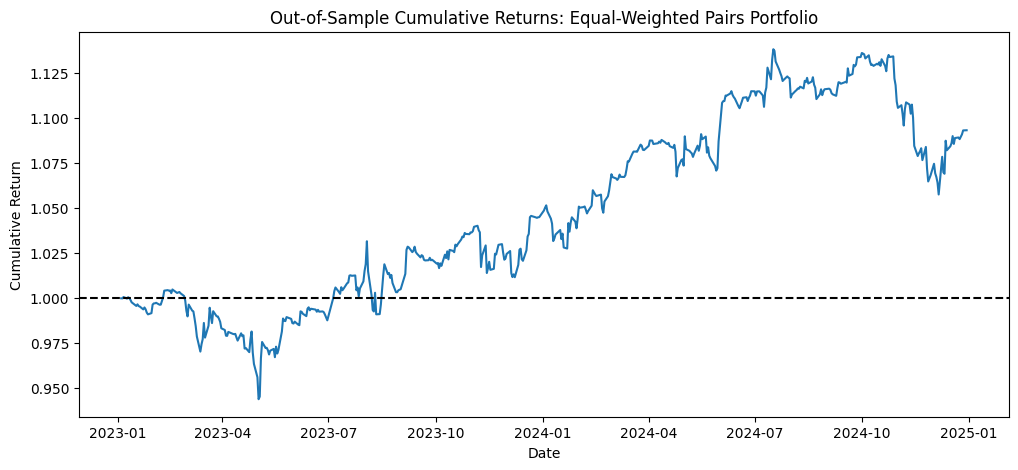

In [318]:
# Combine pair returns into one DataFrame
portfolio_returns_df = pd.DataFrame(portfolio_pair_returns)

# Equal-weighted portfolio return across available pairs each day
portfolio_returns = portfolio_returns_df.mean(axis=1).dropna()

# Portfolio equity curve
portfolio_equity = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(portfolio_equity)
plt.axhline(1, color="black", linestyle="--")

plt.title("Out-of-Sample Cumulative Returns: Equal-Weighted Pairs Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.show()

In [319]:
# For portfolio-level positions, turnover is less clear, so use pair metrics separately.
# Here we pass a dummy position series only to make the function work if needed.

dummy_positions = pd.Series(index=portfolio_returns.index, data=1)

portfolio_metrics = calculate_performance_metrics(
    portfolio_returns,
    dummy_positions
)

pd.Series(portfolio_metrics)
portfolio_returns_df.to_csv("portfolio_pair_returns.csv")
portfolio_pair_metrics_df.to_csv("portfolio_pair_metrics.csv", index=False)

The portfolio cumulative return chart shows the performance of an equal-weighted strategy across multiple candidate pairs. This is useful because relying on one pair can make the strategy sensitive to pair-specific events. A portfolio of pairs can diversify some of this risk.

However, the individual pair results show that performance varies widely across pairs. Some pairs produce strong positive returns, while others perform poorly. This suggests that pair selection remains one of the most important parts of the strategy.

## 9. Results and Interpretation

The final rolling z-score model was evaluated using several checks: out-of-sample performance, transaction costs, sensitivity analysis, trade-level returns, and portfolio-level cumulative returns. These checks are important because the project is not only about finding one profitable backtest, but also about testing whether the strategy is robust.

The final selected pair, Pair 4, produced the strongest balance between return and risk. It achieved high after-cost cumulative return, a strong Sharpe ratio, low maximum drawdown, and a reasonable number of trades. The sensitivity analysis also helps determine whether this result depends too heavily on one exact parameter choice.

The broader portfolio test shows that the same strategy does not work equally well for every pair. Some pairs performed strongly, while others lost money out-of-sample. This confirms that in-sample cointegration is not sufficient by itself. The pair must also continue to mean-revert out-of-sample and survive transaction costs.

## 10. Conclusion

This project built and evaluated a pairs trading strategy using historical stock price data. The goal was to find pairs of stocks whose price relationship showed mean-reverting behavior and then use that relationship to generate trading signals.

The final strategy used a **rolling z-score model**. Instead of comparing the spread to one fixed historical mean and standard deviation, the rolling model updates the spread’s mean and volatility using recent data. This made the strategy more adaptive to changing market conditions and improved out-of-sample performance.

After testing multiple candidate pairs, **Pair 4** was selected as the final pair because it had the strongest overall balance between return and risk. After transaction costs, the strategy achieved a cumulative return of **35.06%**, an annualized return of **16.36%**, annualized volatility of **9.17%**, and a Sharpe ratio of **1.78**. The maximum drawdown was only **-6.07%**, suggesting that the strategy controlled downside risk relatively well.

The results also show that pair selection is very important. Some pairs that looked statistically reasonable in-sample performed poorly out-of-sample. This shows that in-sample stationarity alone is not enough to guarantee a profitable trading strategy. A useful pairs trading model must be tested on out-of-sample data and evaluated after transaction costs.

Overall, the rolling z-score pairs trading strategy produced a strong result for the selected pair. However, the model still has limitations. The backtest only covers one out-of-sample period, and future performance may change if the relationship between the two stocks breaks down. In a more advanced version, the strategy could be improved by testing more time periods, using rolling hedge ratios, adding stop-loss rules, and comparing performance across different market regimes.